# Aggregazione risultati battery run

This notebook aggregates the `battery_results_*.csv` files produced by each run in `tests/battery/results/`, adds the run identifier (`cf0`, `cfg0`, ...) and the execution parameters extracted from the respective `battery_config.json`.

In [1]:

from pathlib import Path
import json
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns

# The working directory of the kernel can be either the repo root or the notebook folder.
# We select the root robustly by looking for tests/battery/results.
candidate_root = Path().resolve()
if (candidate_root / "tests" / "battery" / "results").exists():
    REPO_ROOT = candidate_root
else:
    # Il notebook è in tests/battery: saliamo di due livelli
    REPO_ROOT = candidate_root.parents[1]

RESULTS_DIR = REPO_ROOT / "tests" / "battery" / "results"

# Get folders that look like runs
# prefix_regex = r"^(cf|cfg)\d+_"
# get only cfg runs
# prefix_regex = r"^(cfg)[0-5]+_071[8|7]"
prefix_regex = r"^(cfg)_onlyhigh_[0-5]+_"
prefix_regex = r"^(cfg)_onlyhigh_[0-5]+_0719_16"
run_dirs = sorted(
    d for d in RESULTS_DIR.iterdir()
    if d.is_dir() and re.match(prefix_regex, d.name)
)
print(f"Trovate {len(run_dirs)} run directories")
for d in run_dirs:
    print(" -", d.name)


Trovate 2 run directories
 - cfg_onlyhigh_0_0719_1617_8_roll0_0_T_M
 - cfg_onlyhigh_1_0719_1644_8_roll4_0_T_M


In [2]:
def _scenario_requests_total(run_dir: Path) -> dict:
    """Best-effort scenario_id -> requests_total lookup, read from each scenario's
    summary_by_n.csv / baseline_summary.csv. Used as a fallback for "requests_in"
    when the battery_results CSV predates that column (requests_total is constant
    per scenario_id regardless of infeasibility_mode/batch_size, so a single value
    read anywhere under the scenario folder is enough)."""
    totals = {}
    for scenario_dir in run_dir.iterdir():
        if not scenario_dir.is_dir():
            continue
        for csv_name in ("summary_by_n.csv", "baseline_summary.csv"):
            matches = list(scenario_dir.glob(f"**/{csv_name}"))
            if not matches:
                continue
            summary = pd.read_csv(matches[0])
            if "requests_total" in summary.columns and not summary.empty:
                totals[scenario_dir.name] = int(summary["requests_total"].iloc[0])
                break
    return totals


def load_run(run_dir: Path) -> pd.DataFrame:
    """Loads the results of a run and adds metadata."""
    run_id = run_dir.name.split("_")[0]

    config_path = run_dir / "battery_config.json"
    cfg = json.loads(config_path.read_text()) if config_path.exists() else {}

    # Find the battery_results CSV
    csv_files = list(run_dir.glob("battery_results_*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Nessun battery_results CSV trovato in {run_dir}")
    csv_path = csv_files[0]

    df = pd.read_csv(csv_path)
    df.insert(0, "run_id", run_id)
    df["rollback_max_consecutive"] = cfg.get("rollback_max_consecutive")
    df["parallelism"] = cfg.get("max_batch_solver_parallelism")
    df["online_swarm_mode"] = cfg.get("online_swarm_mode")

    # requests_in: absent in older battery_results CSVs produced before this column
    # was added to run_battery.py's output. Fall back to requests_total read from
    # summary_by_n.csv / baseline_summary.csv, per scenario_id.
    if "requests_in" not in df.columns:
        df["requests_in"] = pd.NA
    missing_requests_in = df["requests_in"].isna()
    if missing_requests_in.any():
        totals = _scenario_requests_total(run_dir)
        df.loc[missing_requests_in, "requests_in"] = df.loc[missing_requests_in, "scenario_id"].map(totals)

    # Join with per_n_timings (elapsed_seconds per scenario/mode/batch_size)
    timing_files = list(run_dir.glob("per_n_timings_*.csv"))
    if timing_files:
        timings = pd.read_csv(timing_files[0])
        # Align naming with battery_results CSV columns
        timings = timings.rename(
            columns={
                "elapsed_seconds": "elapsed_seconds",
                "mode": "infeasibility_mode",
            }
        )
        # battery_results uses "batch_size"; per_n_timings also uses "batch_size"
        df = df.merge(
            timings[["scenario_id", "infeasibility_mode", "batch_size", "elapsed_seconds"]],
            on=["scenario_id", "infeasibility_mode", "batch_size"],
            how="left",
        )

    return df


dfs = [load_run(d) for d in run_dirs]
df_all = pd.concat(dfs, ignore_index=True)

# Rename carbon cost column for brevity
df_all = df_all.rename(columns={"total_carbon_cost": "carbon_cost"})
# rename carbon_cost_saving_vs_baseline_pct to carbon_saving for brevity
df_all = df_all.rename(columns={"carbon_cost_saving_vs_baseline_pct": "carbon_saving"})
# # rename max_batch_solver_parallelism to parallelism for brevity
# df_all = df_all.rename(columns={"max_batch_solver_parallelism": "parallelism"})

print(f"Righe totali: {len(df_all)}")
print(f"Colonne: {list(df_all.columns)}")

# drop "backend" column 
df_all = df_all.drop(columns=["backend"])

# if requests_assigned_with_relaxed_retry is all 0, drop it
if df_all["requests_assigned_with_relaxed_retry"].sum() == 0:
    df_all = df_all.drop(columns=["requests_assigned_with_relaxed_retry"])

# sort columns to match this order
cols = ['run_id',
 'scenario_id',
 'requests_in',
 'batch_size',
 'infeasibility_mode',
 'parallelism',
 'solver_time_ms_avg',
 'elapsed_seconds',
 'carbon_cost',
 'carbon_saving',
 'requests_assigned_with_greedy_fallback',
 'total_rollbacks',
 'peak_consecutive_rollbacks',
 'rollback_max_consecutive',
 'peak_concurrent_workers',
 'avg_concurrent_workers',
 'online_swarm_mode',
 'baseline_carbon_cost',
 'final_global_error',
 'avg_global_error_per_slot',
 ]
df_all = df_all[cols]


Righe totali: 62
Colonne: ['run_id', 'scenario_id', 'backend', 'batch_size', 'infeasibility_mode', 'solver_time_ms_avg', 'carbon_cost', 'final_global_error', 'avg_global_error_per_slot', 'requests_in', 'requests_assigned_with_greedy_fallback', 'requests_assigned_with_relaxed_retry', 'total_rollbacks', 'peak_consecutive_rollbacks', 'baseline_carbon_cost', 'carbon_saving', 'peak_concurrent_workers', 'avg_concurrent_workers', 'rollback_max_consecutive', 'parallelism', 'online_swarm_mode', 'elapsed_seconds']


In [3]:
# set to display all colmuns 
pd.set_option("display.max_columns", None)

# Preview of the aggregated data
display(df_all.head())

# Save the aggregated dataframe
output_csv = RESULTS_DIR / "aggregated_battery_results.csv"
df_all.to_csv(output_csv, index=False)
print(f"Salvato in: {output_csv}")


,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,requests_assigned_with_greedy_fallback,total_rollbacks,peak_consecutive_rollbacks,rollback_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot
0,cfg,high_load_1500_92,70788,1,min_error_greedy,8,7.783441,180.940,51885.170231,77.463123,584,0,0,0,8,6.020879,merge,230223.425095,3.999265,3.999384
1,cfg,high_load_1500_92,70788,4,min_error_greedy,8,8.461788,45.680,50463.181144,78.080779,799,0,0,0,8,6.512420,merge,230223.425095,3.999936,4.003967
2,cfg,high_load_1500_92,70788,6,min_error_greedy,8,16.520149,40.066,51373.452734,77.685393,3095,0,0,0,8,7.122768,merge,230223.425095,4.000042,4.003807
3,cfg,high_load_1500_92,70788,8,min_error_greedy,8,35.669520,48.396,52915.843280,77.015439,7658,0,0,0,8,7.427959,merge,230223.425095,3.999018,3.999198
4,cfg,high_load_1500_92,70788,10,min_error_greedy,8,69.224812,67.475,54790.591818,76.201122,12854,0,0,0,8,7.620758,merge,230223.425095,3.994003,3.994087


Salvato in: /home/francis/unipi/carbonshift/carbonshift/tests/battery/results/aggregated_battery_results.csv


In [4]:
# get values in requests_assigned_with_greedy_fallback column
df_all["requests_assigned_with_greedy_fallback"].value_counts()

# sort rows by total_rollbacks
df_all_sorted = df_all.sort_values(by="total_rollbacks", ascending=False)
df_all_sorted.head(10)

,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,requests_assigned_with_greedy_fallback,total_rollbacks,peak_consecutive_rollbacks,rollback_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot
37,cfg,high_load_1500_92,70788,16,min_error_greedy,8,208.205282,137.504,55610.444366,75.845010,13184,531,4,4,8,7.631745,merge,230223.425095,3.988988,3.989863
44,cfg,high_load_1500_92,70788,16,carryover,8,212.606576,139.509,55044.220078,76.090956,13399,513,3,4,8,7.631969,merge,230223.425095,3.990472,3.990218
36,cfg,high_load_1500_92,70788,12,min_error_greedy,8,106.990376,185.201,55117.450411,76.059148,13168,481,4,4,8,7.634459,merge,230223.425095,3.994921,3.994115
43,cfg,high_load_1500_92,70788,12,carryover,8,111.420965,96.165,55184.995351,76.029809,13111,473,4,4,8,7.631926,merge,230223.425095,3.993579,3.994167
42,cfg,high_load_1500_92,70788,10,carryover,8,70.728182,74.639,54891.034777,76.157494,12703,426,3,4,8,7.595832,merge,230223.425095,3.996193,3.996617
35,cfg,high_load_1500_92,70788,10,min_error_greedy,8,66.483379,70.739,53663.873805,76.690524,9665,415,3,4,8,7.591466,merge,230223.425095,3.999195,3.999742
34,cfg,high_load_1500_92,70788,8,min_error_greedy,8,37.336330,53.992,54566.477594,76.298469,11498,359,3,4,8,7.403157,merge,230223.425095,3.997606,3.998767
41,cfg,high_load_1500_92,70788,8,carryover,8,36.134607,53.376,52319.563404,77.274440,6849,356,3,4,8,7.332920,merge,230223.425095,3.999936,4.000563
33,cfg,high_load_1500_92,70788,6,min_error_greedy,8,17.033920,44.254,51245.039670,77.741170,3878,323,4,4,8,7.071664,merge,230223.425095,3.999901,4.003620
40,cfg,high_load_1500_92,70788,6,carryover,8,17.442385,45.383,51400.891619,77.673475,4269,304,4,4,8,7.107877,merge,230223.425095,4.000219,4.002958


# Analysis section

This is a section I used to get some statistics and plots from the aggregated data with the purpose of gathering insights on the performance of the different configurations. 

In [5]:
# get max of requests_assigned_with_greedy_fallback
df_all["requests_assigned_with_greedy_fallback"].max()
# df_all["requests_assigned_with_relaxed_retry"].max()

display(df_all["scenario_id"].value_counts())
display(df_all["infeasibility_mode"].value_counts())

scenario_id
high_load_1500_92    62
Name: count, dtype: int64

infeasibility_mode
min_error_greedy           14
carryover                  14
online_ant_colony          14
online_bandit              14
offline_greedy_cheapest     2
offline_ant_colony          2
offline_bandit              2
Name: count, dtype: int64

In [26]:
# Sort by scenario_id and then by carbon cost
df_all_sorted_by_scenario = df_all.sort_values(by=["scenario_id", "carbon_cost"])
# Get only the first 5 rows for each scenario_id (the one with the lowest carbon cost)
df_top5_per_scenario = df_all_sorted_by_scenario.groupby("scenario_id").head(5)

# Filter to get infeasibility_mode = "min_error_greedy"|"carryover"
df_filtered = df_all_sorted_by_scenario[
    df_all_sorted_by_scenario["infeasibility_mode"].isin(["min_error_greedy", "carryover"])
]

# display up to 200 rows
pd.set_option("display.max_rows", 200)

df_top5_per_scenario.tail(20)

'''
low_load_500_2028        144
medium_load_1000_2030    144
high_load_1500_92        144
xhigh_load_2000_120      144
'''


# filter to get only scenario "high_load_1500_92"
df_high_load_1500_92 = df_all_sorted_by_scenario[
    df_all_sorted_by_scenario["scenario_id"] == "high_load_1500_92"
]

# filter to avoid parallelism = 1
df_high_load_1500_92 = df_high_load_1500_92[df_high_load_1500_92["parallelism"] > 1]

# display(df_high_load_1500_92[df_high_load_1500_92["infeasibility_mode"] == "min_error_greedy"].sort_values(by="carbon_cost"))
display(df_high_load_1500_92[df_high_load_1500_92["infeasibility_mode"] == "carryover"].sort_values(by=["batch_size","rollback_max_consecutive"]))
df_high_load_1500_92[df_high_load_1500_92["infeasibility_mode"] == "offline_greedy_cheapest"].sort_values(by="carbon_cost")

,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,requests_assigned_with_greedy_fallback,total_rollbacks,peak_consecutive_rollbacks,rollback_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot
7,cfg,high_load_1500_92,70788,1,carryover,8,7.860292,181.795,52033.946014,77.398501,600,0,0,0,8,6.048568,merge,230223.425095,3.998382,3.999469
38,cfg,high_load_1500_92,70788,1,carryover,8,8.175273,187.846,51130.532468,77.790908,321,54,1,4,8,5.984955,merge,230223.425095,3.999371,4.000051
8,cfg,high_load_1500_92,70788,4,carryover,8,8.681734,47.017,50552.197459,78.042114,695,0,0,0,8,6.529073,merge,230223.425095,3.999830,4.005245
39,cfg,high_load_1500_92,70788,4,carryover,8,9.331960,50.833,50670.467544,77.990742,1000,200,2,4,8,6.453709,merge,230223.425095,3.999336,4.003854
9,cfg,high_load_1500_92,70788,6,carryover,8,17.016635,41.064,51717.617014,77.535901,4599,0,0,0,8,7.133091,merge,230223.425095,3.999830,4.002705
40,cfg,high_load_1500_92,70788,6,carryover,8,17.442385,45.383,51400.891619,77.673475,4269,304,4,4,8,7.107877,merge,230223.425095,4.000219,4.002958
10,cfg,high_load_1500_92,70788,8,carryover,8,35.603295,48.454,52252.181600,77.303708,6529,0,0,0,8,7.422210,merge,230223.425095,4.000184,4.000725
41,cfg,high_load_1500_92,70788,8,carryover,8,36.134607,53.376,52319.563404,77.274440,6849,356,3,4,8,7.332920,merge,230223.425095,3.999936,4.000563
11,cfg,high_load_1500_92,70788,10,carryover,8,68.828391,67.181,54634.676230,76.268846,11485,0,0,0,8,7.630052,merge,230223.425095,3.995381,3.996504
42,cfg,high_load_1500_92,70788,10,carryover,8,70.728182,74.639,54891.034777,76.157494,12703,426,3,4,8,7.595832,merge,230223.425095,3.996193,3.996617


,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,requests_assigned_with_greedy_fallback,total_rollbacks,peak_consecutive_rollbacks,rollback_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot
14,cfg,high_load_1500_92,70788,0,offline_greedy_cheapest,8,0.0,7.730,49970.172812,78.294923,0,0,0,0,0,0.0,merge,230223.425095,3.999054,3.999596
45,cfg,high_load_1500_92,70788,0,offline_greedy_cheapest,8,0.0,7.804,49970.172812,78.294923,0,0,0,4,0,0.0,merge,230223.425095,3.999054,3.999596


<Axes: >

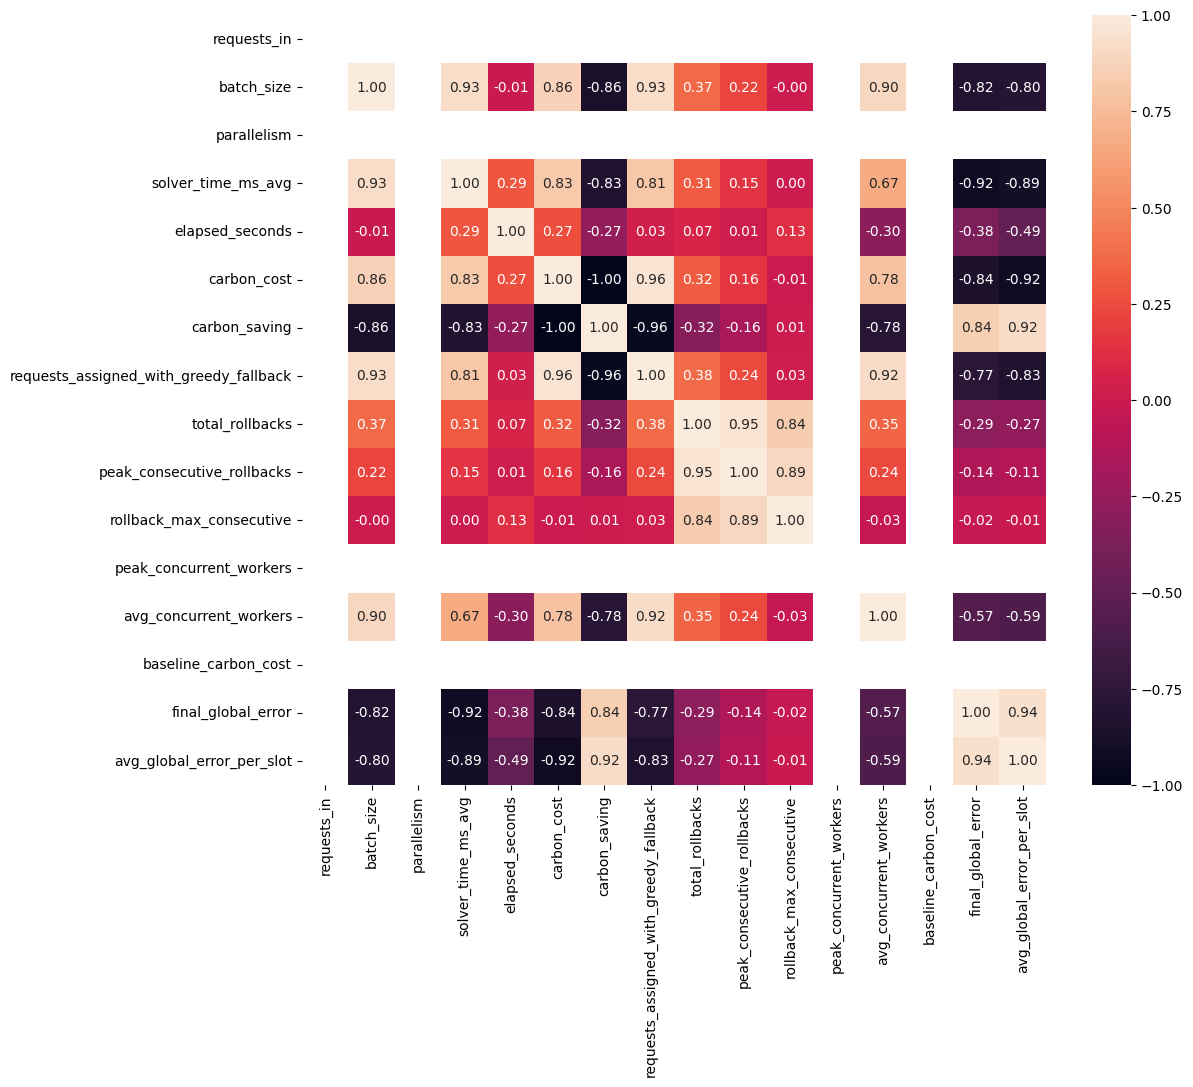

In [7]:
# get only numeric columns
numeric_cols = df_all.select_dtypes(include=["number"]).columns

# get only min_error_greedy and carryover rows
df_greedy_carryover = df_all[df_all["infeasibility_mode"].isin(["min_error_greedy", "carryover"])]
# Display correlation matrix for numeric columns
corr_matrix = df_greedy_carryover[numeric_cols].corr()
# make heatmap big
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")



## Carryover vs min_error_greedy

In [8]:

# Count carryover vs min_error_greedy in the top 5 per scenario
count_modes = df_top5_per_scenario["infeasibility_mode"].value_counts()
print(count_modes)

# Avg elapsed_seconds per mode 
# get rows where infeasibility_mode does not include "offline"
df_online_modes = df_all[~df_all["infeasibility_mode"].str.contains("offline")]
avg_elapsed_seconds_per_mode = df_online_modes.groupby("infeasibility_mode")["elapsed_seconds"].mean()
print(avg_elapsed_seconds_per_mode)
avg_elapsed_seconds_per_mode = df_top5_per_scenario.groupby("infeasibility_mode")["elapsed_seconds"].mean()
print(avg_elapsed_seconds_per_mode)

# Avg carbon cost per mode
avg_carbon_cost_per_mode = df_online_modes.groupby("infeasibility_mode")["carbon_cost"].mean()
print(avg_carbon_cost_per_mode)



infeasibility_mode
offline_greedy_cheapest    2
min_error_greedy           2
carryover                  1
Name: count, dtype: int64
infeasibility_mode
carryover            88.742286
min_error_greedy     94.115429
online_ant_colony    15.048071
online_bandit        21.464429
Name: elapsed_seconds, dtype: float64
infeasibility_mode
carryover                  47.0170
min_error_greedy           47.7535
offline_greedy_cheapest     7.7670
Name: elapsed_seconds, dtype: float64
infeasibility_mode
carryover            53006.490476
min_error_greedy     53217.880916
online_ant_colony    78438.147827
online_bandit        65781.679949
Name: carbon_cost, dtype: float64


In [9]:
# install seaborn
# !pip install seaborn

###

In [10]:
# import seaborn as sns
# import matplotlib.pyplot as plt


# df_gr_ret = df_all[~df_all["infeasibility_mode"].str.contains("offline|online")]
# plt.figure(figsize=(10,10))


# sns.boxplot(
#     data=df_gr_ret,
#     x="scenario_id",
#     y="carbon_saving",
#     hue="infeasibility_mode",
#     showfliers=True,
# )

# plt.xlabel("Scenario ID")
# plt.ylabel("Carbon Saving")
# plt.title("Carbon Saving by Scenario and Infeasibility Mode")
# plt.xticks(rotation=90)
# plt.tight_layout()
# # plt.show()

## Carryover vs min_error_greedy
Overall min_error_greedy is in general faster and yields the same results as carryover.\
However, considering only top 5 runs per scenario, both the carbon cost and the elapsed time are basically the same.\
In general, it could be better to use min_error_greedy, as it is faster and yields the same results.

These tests were run with the following `carryover` parameters:
```
infeasibility_recovery_mode: "carryover_last_slot".to_string(),
infeasibility_mock_influence: 0.6,
infeasibility_mock_influence_decay_step: 0.15,
```
That is, in case of infeasibility, the algorithm will consider the previous slot's assignment with a weight of 0.6 to influence the current slot's assignment. The weight will decay by 0.15 at every subsequent slot where infeasibility occurs. This means that the algorithm will try to "carry over" the previous slot's assignment to the current slot, but with decreasing influence as more infeasibility occurs.\
The mechanism is designed to help the solver not to "panic" and try to assign requests knowing that others will come, allowing to mitigate the error average.

This probably results in being only partially effective due to the decayed window, which kind of embeds this idea already.


## Rollback and Parallelism


In [11]:
# Let's understand if more parallelism yields less elapsed_time
# Get only carryover and min_error_greedy modes
df_gr_ret = df_all[~df_all["infeasibility_mode"].str.contains("offline|online")]
# For each scenario and for each N, we want to know a much elapsed_time is spared with runs having parallelism > 1 compared to runs with parallelism = 1
group_cols = ["scenario_id", "batch_size"]

# Baseline: prendiamo il max elapsed_seconds tra le run con parallelism=1
baseline = (
    df_gr_ret[df_gr_ret["parallelism"] == 1]
    .groupby(group_cols)
    .agg(
        elapsed_parallelism_1=("elapsed_seconds", "max"),
    )
    .reset_index()
)

# Run con parallelism > 1
parallel = (
    df_gr_ret[df_gr_ret["parallelism"] > 1]
    [
        group_cols
        + [
            "parallelism",
            "elapsed_seconds",
            "peak_concurrent_workers",
            "avg_concurrent_workers",
            "infeasibility_mode",
            "rollback_max_consecutive",
            "total_rollbacks",
            "carbon_saving"
        ]
    ]
)

# confronto
comparison = parallel.merge(
    baseline,
    on=group_cols,
    how="inner",
)

comparison["seconds_saved"] = (
    comparison["elapsed_parallelism_1"]
    - comparison["elapsed_seconds"]
)

comparison["speedup_pct"] = (
    comparison["seconds_saved"]
    / comparison["elapsed_parallelism_1"]
    * 100
)

# Set columns ordering for comparison for better readability
comparison = comparison[
    [
        "scenario_id",
        "batch_size",
        "parallelism",
        "elapsed_seconds",
        "elapsed_parallelism_1",
        "seconds_saved",
        "speedup_pct",
        "carbon_saving",
        "peak_concurrent_workers",
        "avg_concurrent_workers",
        "infeasibility_mode",
        "rollback_max_consecutive",
        "total_rollbacks",
    ]
] 

display(comparison.head())
# comparison
# display for scenario xxhigh_load_2081
# display(comparison[(comparison["scenario_id"] == "xxhigh_load_2081") & (comparison["batch_size"] == 16)])
# display(comparison[(comparison["scenario_id"] == "high_load_105") & (comparison["batch_size"] == 16)])
# display(comparison[(comparison["scenario_id"] == "low_load_2028") & (comparison["batch_size"] == 16)])


summary = (
    comparison
    .groupby("parallelism")
    .agg(
        runs=("scenario_id", "count"),
        avg_saved_seconds=("seconds_saved", "mean"),
        median_saved_seconds=("seconds_saved", "median"),
        avg_speedup_pct=("speedup_pct", "mean"),
        median_speedup_pct=("speedup_pct", "median"),
        avg_peak_workers=("peak_concurrent_workers", "mean"),
        avg_workers=("avg_concurrent_workers", "mean"),
        avg_rollbacks=("total_rollbacks", "mean"),
    )
)

summary

,scenario_id,batch_size,parallelism,elapsed_seconds,elapsed_parallelism_1,seconds_saved,speedup_pct,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,infeasibility_mode,rollback_max_consecutive,total_rollbacks


,runs,avg_saved_seconds,median_saved_seconds,avg_speedup_pct,median_speedup_pct,avg_peak_workers,avg_workers,avg_rollbacks
parallelism,,,,,,,,


### Commenti su rollback e parallelismo
Per lo scenario a bassa intensità sembra che rollback non porti vantaggi in termini di risparmio carbonio, mentre per lo scenario ad alta intensità sembra che rollback porti a un risparmio di carbonio maggiore, di circa 3-4% rispetto a non usare rollback con parallelismo a 20 worker, mentre nessun vantaggio con parallelismo a 8 worker.

Non sembra ci sia significativo vantaggio nell'usare parallelismo a 20 worker rispetto a 8 worker.

In generale il parallelismo porta a un significativo risparmio di tempo di esecuzione.

I rollback *non* sembrano indurre un significativo risparmio di carbonio.

Il tempo di esecuzione sembra poter aver subito influenza di fattori esterni, come la disponibilità di risorse della macchina, che può aver influito sul parallelismo e quindi sul tempo di esecuzione. Questo è alquanto spiacevole.


In [12]:
    # Count values of rollback_max_consecutive and parallelism for the top 5 per scenario
count_rollback_max_consecutive = df_top5_per_scenario["rollback_max_consecutive"].value_counts()
count_parallelism = df_top5_per_scenario["parallelism"].value_counts()
#average roll

print("Count of rollback_max_consecutive in top 5 per scenario:")
print(count_rollback_max_consecutive)
print("\nCount of parallelism in top 5 per scenario:")
print(count_parallelism)

Count of rollback_max_consecutive in top 5 per scenario:
rollback_max_consecutive
0    3
4    2
Name: count, dtype: int64

Count of parallelism in top 5 per scenario:
parallelism
8    5
Name: count, dtype: int64


Non incredibilmente, sembra che i migliori risultati si ottengano con parallelismo a 1, non c'è concorrenza e non c'è rischio di fare assegnamenti basati su informazioni stale, potenzialmente sforando un cap level e avendo un costo superiore a quello previsto.

In [13]:
# get top5 but filter out parallelism = 1
df_all_sorted_by_scenario_filtered = df_all_sorted_by_scenario[df_all_sorted_by_scenario["parallelism"] != 1]
df_top5_per_scenario = df_all_sorted_by_scenario_filtered.groupby("scenario_id").head(5)

df_top5_per_scenario

,run_id,scenario_id,requests_in,batch_size,infeasibility_mode,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,requests_assigned_with_greedy_fallback,total_rollbacks,peak_consecutive_rollbacks,rollback_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot
14,cfg,high_load_1500_92,70788,0,offline_greedy_cheapest,8,0.000000,7.730,49970.172812,78.294923,0,0,0,0,0,0.000000,merge,230223.425095,3.999054,3.999596
45,cfg,high_load_1500_92,70788,0,offline_greedy_cheapest,8,0.000000,7.804,49970.172812,78.294923,0,0,0,4,0,0.000000,merge,230223.425095,3.999054,3.999596
1,cfg,high_load_1500_92,70788,4,min_error_greedy,8,8.461788,45.680,50463.181144,78.080779,799,0,0,0,8,6.512420,merge,230223.425095,3.999936,4.003967
32,cfg,high_load_1500_92,70788,4,min_error_greedy,8,9.185769,49.827,50488.211007,78.069907,688,186,2,4,8,6.417015,merge,230223.425095,3.999830,4.002942
8,cfg,high_load_1500_92,70788,4,carryover,8,8.681734,47.017,50552.197459,78.042114,695,0,0,0,8,6.529073,merge,230223.425095,3.999830,4.005245


In [14]:
# get average carbon saving for all modes
average_carbon_saving = df_all.groupby("infeasibility_mode")["carbon_saving"].mean()
display(average_carbon_saving)

# get max carbon saving value for online_ant_colony mode with parallelism = 1 and online_swarm_mode = serialized
max_carbon_saving = df_all[
    (df_all["infeasibility_mode"] == "online_ant_colony") &
    (df_all["parallelism"] == 1) &
    (df_all["online_swarm_mode"] == "serialized")
]["carbon_saving"].max()
display(max_carbon_saving)


infeasibility_mode
carryover                  76.976066
min_error_greedy           76.884246
offline_ant_colony         76.841388
offline_bandit             72.667243
offline_greedy_cheapest    78.294923
online_ant_colony          65.929554
online_bandit              71.427026
Name: carbon_saving, dtype: float64

nan

## Quali combinazioni di parametri portano a un carbon saving maggiore?

Analisi limitata a `infeasibility_mode == "min_error_greedy"`. Campi esaminati: `parallelism`, `rollback_max_consecutive`, `batch_size`, `requests_in`, `total_rollbacks`.

In [15]:
FEATURES = ["parallelism", "rollback_max_consecutive", "batch_size", "requests_in", "total_rollbacks","avg_concurrent_workers"]
TARGET = "carbon_saving"

df_gf_raw = df_all[df_all["infeasibility_mode"] == "min_error_greedy"].copy()
# filter to avoid parallelism = 1
df_gf_raw = df_gf_raw[df_gf_raw["parallelism"] > 1]

# Older battery_results CSVs (produced before "requests_in" was added to run_battery.py's
# output) have it entirely NaN. Drop such all-missing features instead of losing every row.
all_missing = [f for f in FEATURES if df_gf_raw[f].isna().all()]
if all_missing:
    print(f"Campi esclusi (assenti in tutte le run selezionate): {all_missing}")
FEATURES = [f for f in FEATURES if f not in all_missing]

df_gf = df_gf_raw.dropna(subset=FEATURES + [TARGET]).copy()
print(f"Righe min_error_greedy: {len(df_gf)}")
df_gf[FEATURES + [TARGET]].describe()


Righe min_error_greedy: 14


,parallelism,rollback_max_consecutive,batch_size,requests_in,total_rollbacks,avg_concurrent_workers,carbon_saving
count,14.0,14.000000,14.000000,14.0,14.000000,14.000000,14.000000
mean,8.0,2.000000,8.142857,70788.0,168.000000,7.121737,76.884246
std,0.0,2.075498,4.849380,0.0,207.821299,0.627806,0.842877
min,8.0,0.000000,1.000000,70788.0,0.000000,5.966421,75.845010
25%,8.0,0.000000,4.500000,70788.0,0.000000,6.652231,76.094641
50%,8.0,2.000000,8.000000,70788.0,28.500000,7.415558,76.852982
75%,8.0,4.000000,11.500000,70788.0,350.000000,7.628998,77.629825
max,8.0,4.000000,16.000000,70788.0,531.000000,7.651858,78.080779


### Correlazione con `carbon_saving`

Prima approssimazione: correlazione lineare (Pearson) di ciascun campo con `carbon_saving`. Valori positivi indicano che crescere quel parametro tende ad aumentare il risparmio di carbonio.

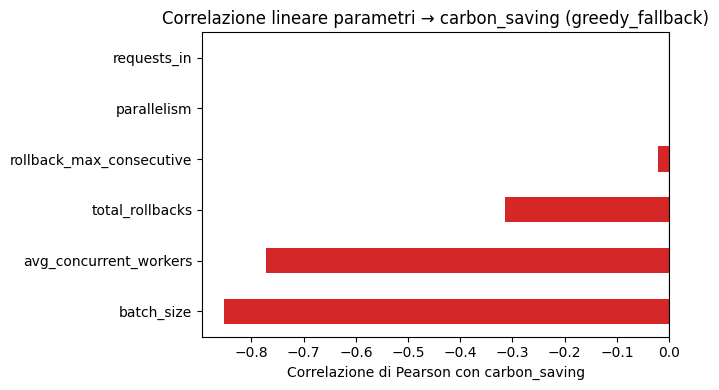

In [16]:
corr_with_target = df_gf[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(7, 4))
colors = ["tab:red" if v < 0 else "tab:green" for v in corr_with_target.values]
corr_with_target.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlazione di Pearson con carbon_saving")
plt.title("Correlazione lineare parametri → carbon_saving (greedy_fallback)")
plt.tight_layout()
plt.show()


### Vista multidimensionale (PCA)

Le 5 variabili vengono standardizzate e proiettate in 2 componenti principali; ogni punto è colorato in base al `carbon_saving` osservato. Le frecce mostrano il contributo (loading) di ciascun campo alle due componenti: punti/regioni che si trovano nella stessa direzione di una freccia tendono ad avere valori più alti di quel campo. Questo aiuta a individuare visivamente quali *combinazioni* di parametri (non solo singoli valori) sono associate a un carbon saving più alto.

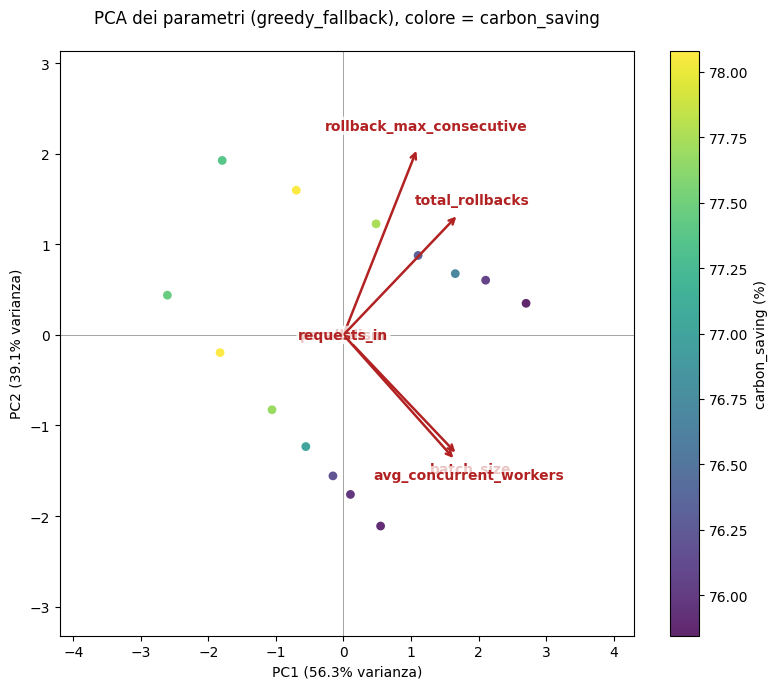

In [17]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df_gf[FEATURES])
pca = PCA(n_components=2)
scores = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(
    scores[:, 0], scores[:, 1],
    c=df_gf[TARGET], cmap="viridis", s=40, alpha=0.85, edgecolor="none",
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("carbon_saving (%)")

# Biplot: draw feature loadings as arrows scaled to the score range for readability.
loadings = pca.components_.T  # shape (n_features, 2)
scale = np.abs(scores).max() * 1.15
for i, feat in enumerate(FEATURES):
    ax.annotate(
        "", xy=(loadings[i, 0] * scale, loadings[i, 1] * scale), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="firebrick", lw=1.8),
    )
    ax.text(
        loadings[i, 0] * scale * 1.12, loadings[i, 1] * scale * 1.12, feat,
        color="firebrick", fontsize=10, ha="center", va="center", weight="bold",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.75),
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("PCA dei parametri (greedy_fallback), colore = carbon_saving", pad=20)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.margins(0.3)  # extra room so loading labels don't get clipped/overlap the frame or title
plt.tight_layout()
plt.show()


### `batch_size` × `parallelism`: carbon saving medio

Heatmap del `carbon_saving` medio per ogni combinazione di `batch_size` e `parallelism` (sempre limitata a `greedy_fallback`); il numero in ogni cella è il numero di run osservate.

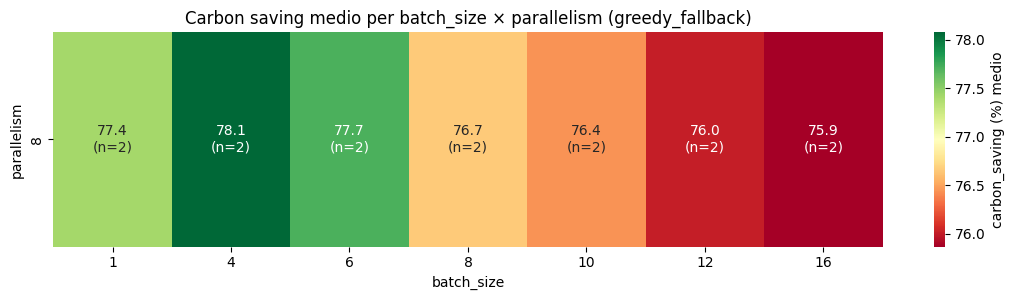

In [18]:
pivot_mean = df_gf.pivot_table(
    index="parallelism", columns="batch_size", values=TARGET, aggfunc="mean"
).sort_index(ascending=False)
pivot_count = df_gf.pivot_table(
    index="parallelism", columns="batch_size", values=TARGET, aggfunc="count"
).sort_index(ascending=False)

annot = pivot_mean.round(1).astype(str) + "\n(n=" + pivot_count.fillna(0).astype(int).astype(str) + ")"

plt.figure(figsize=(1.3 * len(pivot_mean.columns) + 2, 1.1 * len(pivot_mean.index) + 2))
sns.heatmap(
    pivot_mean, annot=annot, fmt="", cmap="RdYlGn", cbar_kws={"label": "carbon_saving (%) medio"},
)
plt.xlabel("batch_size")
plt.ylabel("parallelism")
plt.title("Carbon saving medio per batch_size × parallelism (greedy_fallback)")
plt.tight_layout()
plt.show()


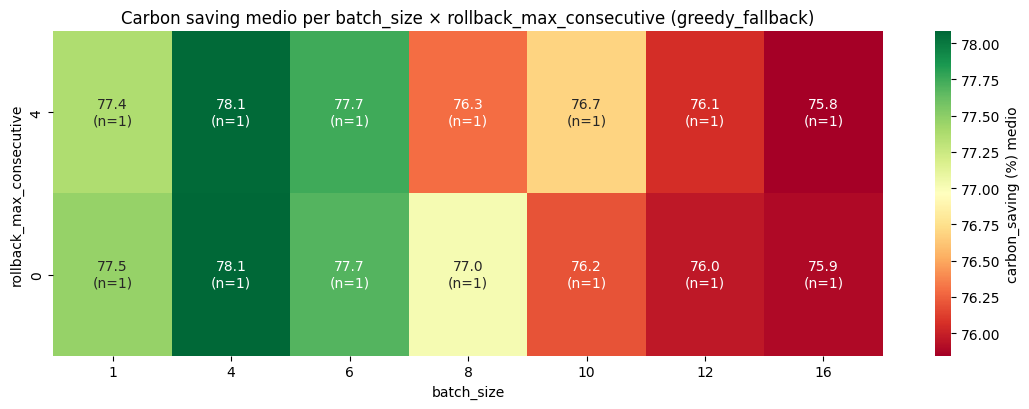

In [19]:
pivot_mean = df_gf.pivot_table(
    index="rollback_max_consecutive", columns="batch_size", values=TARGET, aggfunc="mean"
).sort_index(ascending=False)
pivot_count = df_gf.pivot_table(
    index="rollback_max_consecutive", columns="batch_size", values=TARGET, aggfunc="count"
).sort_index(ascending=False)

annot = pivot_mean.round(1).astype(str) + "\n(n=" + pivot_count.fillna(0).astype(int).astype(str) + ")"

plt.figure(figsize=(1.3 * len(pivot_mean.columns) + 2, 1.1 * len(pivot_mean.index) + 2))
sns.heatmap(
    pivot_mean, annot=annot, fmt="", cmap="RdYlGn", cbar_kws={"label": "carbon_saving (%) medio"},
)
plt.xlabel("batch_size")
plt.ylabel("rollback_max_consecutive")
plt.title("Carbon saving medio per batch_size × rollback_max_consecutive (greedy_fallback)")
plt.tight_layout()
plt.show()


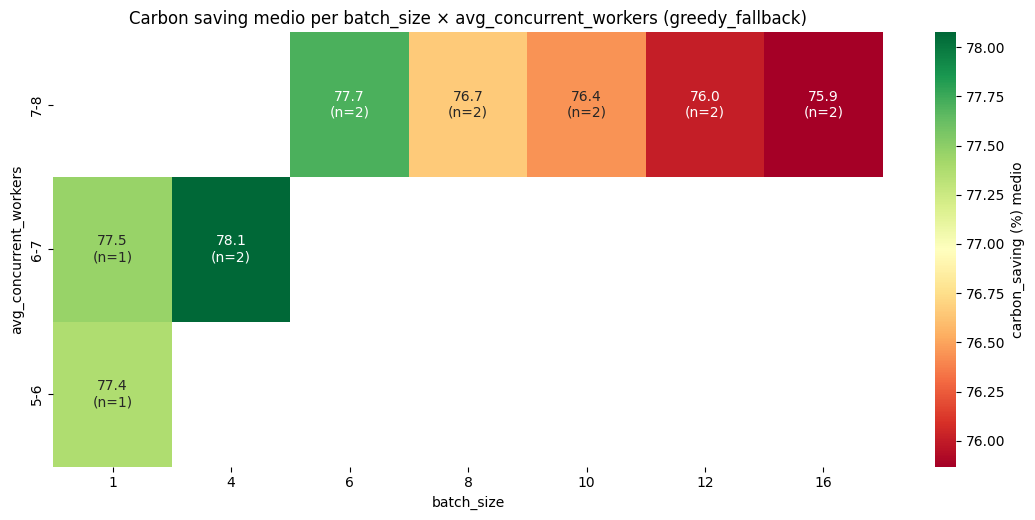

In [20]:
# discretize avg_concurrent_workers into 10 bins, the first 9 must represent values in 0-1, 1-2, 2-3, ... and the last one will be 10+
# Work on a copy so we don't overwrite the numeric column in df_gf (reused by later cells).
df_workers_binned = df_gf.copy()
df_workers_binned["avg_concurrent_workers"] = pd.cut(
    df_workers_binned["avg_concurrent_workers"],
    bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, np.inf],
    labels=["0-1", "1-2", "2-3", "3-4", "4-5", "5-6", "6-7", "7-8", "8-9", "10+"],
)

pivot_mean = df_workers_binned.pivot_table(
    index="avg_concurrent_workers", columns="batch_size", values=TARGET, aggfunc="mean", observed=True,
).sort_index(ascending=False)
pivot_count = df_workers_binned.pivot_table(
    index="avg_concurrent_workers", columns="batch_size", values=TARGET, aggfunc="count", observed=True,
).reindex(index=pivot_mean.index, columns=pivot_mean.columns)

# n indicates the number of runs for each cell in the heatmap
annot = pivot_mean.round(1).astype(str) + "\n(n=" + pivot_count.fillna(0).astype(int).astype(str) + ")"

plt.figure(figsize=(1.3 * len(pivot_mean.columns) + 2, 1.1 * len(pivot_mean.index) + 2))
sns.heatmap(
    pivot_mean, annot=annot, fmt="", cmap="RdYlGn", cbar_kws={"label": "carbon_saving (%) medio"},
)
plt.xlabel("batch_size")
plt.ylabel("avg_concurrent_workers")
plt.title("Carbon saving medio per batch_size × avg_concurrent_workers (greedy_fallback)")
plt.tight_layout()
plt.show()


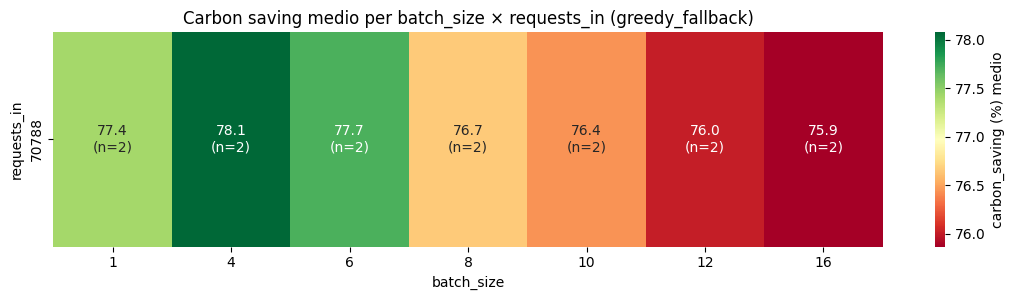

In [21]:
pivot_mean = df_gf.pivot_table(
    index="requests_in", columns="batch_size", values=TARGET, aggfunc="mean"
).sort_index(ascending=False)
pivot_count = df_gf.pivot_table(
    index="requests_in", columns="batch_size", values=TARGET, aggfunc="count"
).sort_index(ascending=False)

annot = pivot_mean.round(1).astype(str) + "\n(n=" + pivot_count.fillna(0).astype(int).astype(str) + ")"

plt.figure(figsize=(1.3 * len(pivot_mean.columns) + 2, 1.1 * len(pivot_mean.index) + 2))
sns.heatmap(
    pivot_mean, annot=annot, fmt="", cmap="RdYlGn", cbar_kws={"label": "carbon_saving (%) medio"},
)
plt.xlabel("batch_size")
plt.ylabel("requests_in")
plt.title("Carbon saving medio per batch_size × requests_in (greedy_fallback)")
plt.tight_layout()
plt.show()


In [22]:
# get avg carbon saving for infeasibility_mode = greedy_fallback and batch_size = 1
df_gf_parallelism_1 = df_all[
    (df_all["infeasibility_mode"] == "greedy_fallback") &
    (df_all["batch_size"] == 1)
]
# get avg carbon saving for infeasibility_mode = offline_greedy_cheapest and whatever batch_size
df_gc_parallelism_1 = df_all[
    (df_all["infeasibility_mode"] == "offline_greedy_cheapest")]

display(df_gf_parallelism_1.groupby("batch_size")["carbon_saving"].mean())
# get avg carbon saving for infeasibility_mode = offline_greedy_cheapest and whatever batch_size
display(df_gc_parallelism_1["carbon_saving"].mean())

Series([], Name: carbon_saving, dtype: float64)

np.float64(78.29492251219897)